# Einfluss von Finanznachrichten auf Währungspaare

**Ziel:** Untersuchen, ob das Sentiment von Finanznachrichten (EODHD News) einen erkennbaren Einfluss auf die Kursentwicklung der Währungspaare **EUR/USD**, **EUR/CHF** und **GBP/USD** hat.

**Datenquellen:**
- Forex-Kurse: **Yahoo Finance** und **EODHD** (MetaTrader wird in diesem Notebook bewusst ignoriert)
- News + Sentiment: **EODHD News API** (Spalte `polarity` im Bereich -1 … +1 als Haupt-Sentimentwert)

**Vorgehen (5 Schritte):**
1. Vergleich der Kurse aus Yahoo und EODHD für dasselbe Datum (wie unterschiedlich sind die Quellen?)
2. Lückenfüllung: Ein neues CSV pro Paar, in dem fehlende Tage (Wochenenden/Feiertage) **linear interpoliert** werden
3. Quellen-Mittelwert: Ein neues CSV pro Paar mit dem Mittelwert von Yahoo und EODHD – nur für Daten, an denen **beide** Quellen einen Wert haben
4. Visualisierung: Kurs- und Sentiment-Verlauf überlagert (täglich, wöchentlich, monatlich)
5. Diskussion / kurze Auswertung


## Setup

Importe, Pfade und Konstanten. Alle Pfade sind relativ zum Notebook-Ort (`notebooks/datenverarbeitung/`).

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# Pfade
RAW_DIR       = Path('../../data/raw')
PROCESSED_DIR = Path('../../data/processed/forex')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Untersuchte Währungspaare. Mapping: interner Name -> Dateinamen-Suffix in den Rohdaten
PAIRS = ['EUR_USD', 'EUR_CHF', 'GBP_USD']

# Datumsbereich der Rohdaten (in den Dateinamen enthalten)
DATE_RANGE = '2022-01-01_to_2026-03-25'

# Welche OHLC-Spalten wir durchgängig verwenden wollen
OHLC_COLS = ['open', 'high', 'low', 'close']

## Hilfsfunktionen zum Laden der Rohdaten

Yahoo und EODHD haben unterschiedliche Spaltennamen und Datumsformate. Wir bringen beide in ein **einheitliches Schema**:
Index = `date` (datetime, ohne Zeitzone), Spalten = `open, high, low, close`.

In [2]:
def load_yahoo(pair: str) -> pd.DataFrame:
    """Lädt ein Yahoo-Forex-CSV und normalisiert Spalten + Datum."""
    path = RAW_DIR / 'forex' / 'yahoo' / f'{pair}_{DATE_RANGE}.csv'
    df = pd.read_csv(path)
    # Yahoo: 'Date' ist tz-aware (UTC) -> wir entfernen die Zeitzone und behalten nur das Datum
    df['date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None).dt.normalize()
    df = df.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'})
    return df.set_index('date')[OHLC_COLS].sort_index()


def load_eodhd(pair: str) -> pd.DataFrame:
    """Lädt ein EODHD-Forex-CSV und normalisiert Spalten + Datum."""
    path = RAW_DIR / 'forex' / 'eodhd' / f'{pair}_{DATE_RANGE}.csv'
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    return df.set_index('date')[OHLC_COLS].sort_index()


# Alle Quellen einlesen und in einem verschachtelten Dict ablegen:
#   raw_data[pair]['yahoo' | 'eodhd'] -> DataFrame
raw_data = {
    pair: {
        'yahoo': load_yahoo(pair),
        'eodhd': load_eodhd(pair),
    }
    for pair in PAIRS
}

# Kurzer Sanity-Check
for pair, sources in raw_data.items():
    for src, df in sources.items():
        print(f'{pair:8s} {src:6s} | {len(df):5d} Zeilen | {df.index.min().date()} – {df.index.max().date()}')

EUR_USD  yahoo  |  1097 Zeilen | 2022-01-03 – 2026-03-24
EUR_USD  eodhd  |  1384 Zeilen | 2022-01-02 – 2026-03-24
EUR_CHF  yahoo  |  1097 Zeilen | 2022-01-03 – 2026-03-24
EUR_CHF  eodhd  |  1151 Zeilen | 2022-01-03 – 2026-03-25
GBP_USD  yahoo  |  1097 Zeilen | 2022-01-03 – 2026-03-24
GBP_USD  eodhd  |  1387 Zeilen | 2022-01-02 – 2026-03-24


## Schritt 1 — Quellenvergleich: Wie unterschiedlich sind Yahoo und EODHD?

Wir joinen beide Quellen pro Paar **innerlich auf das Datum** (nur Tage, an denen beide Quellen einen Wert liefern) und berechnen die Differenzen für Open/High/Low/Close.

Ausgewertet werden:
- absolute Differenz (in Pips bzw. Kurspunkten)
- relative Differenz in %
- Mittelwert, Median, Max der Abweichung

So sehen wir, wie stark sich die beiden Datenquellen für **dieselbe Instanz (Datum)** unterscheiden.

In [3]:
def compare_sources(pair: str) -> pd.DataFrame:
    """Inner-Join Yahoo vs. EODHD für ein Paar und berechne Differenzen."""
    yh = raw_data[pair]['yahoo'].add_suffix('_yahoo')
    ed = raw_data[pair]['eodhd'].add_suffix('_eodhd')
    merged = yh.join(ed, how='inner')
    for col in OHLC_COLS:
        merged[f'{col}_diff_abs'] = merged[f'{col}_yahoo'] - merged[f'{col}_eodhd']
        merged[f'{col}_diff_pct'] = (merged[f'{col}_diff_abs'] / merged[f'{col}_eodhd']) * 100
    return merged

comparisons = {pair: compare_sources(pair) for pair in PAIRS}

# Übersichts-Tabelle: durchschnittliche / maximale relative Abweichung pro Paar
summary_rows = []
for pair, df in comparisons.items():
    for col in OHLC_COLS:
        s = df[f'{col}_diff_pct'].abs()
        summary_rows.append({
            'pair': pair,
            'feld': col,
            'gemeinsame_tage': len(df),
            'mean_abw_%': s.mean(),
            'median_abw_%': s.median(),
            'max_abw_%': s.max(),
        })
summary_df = pd.DataFrame(summary_rows)
summary_df

,pair,feld,gemeinsame_tage,mean_abw_%,median_abw_%,max_abw_%
0,EUR_USD,open,1097,0.185852,0.060943,1.680502
1,EUR_USD,high,1097,0.175890,0.071860,2.199217
2,EUR_USD,low,1097,0.172346,0.078938,1.725061
3,EUR_USD,close,1097,0.227048,0.059218,2.826343
4,EUR_CHF,open,1000,0.143992,0.041689,1.958837
5,EUR_CHF,high,1000,0.121897,0.023611,1.905909
6,EUR_CHF,low,1000,0.128817,0.041724,2.567550
7,EUR_CHF,close,1000,0.156967,0.061730,1.958837
8,GBP_USD,open,1097,0.191766,0.036660,3.054521
9,GBP_USD,high,1097,0.190767,0.086859,2.063530


### Absolute Differenzen pro Tag (Yahoo − EODHD)

Bevor wir aggregieren, schauen wir uns die **rohen Differenzen pro Datum** an: für jedes OHLC-Feld der Wert `yahoo - eodhd` in Kurspunkten (nicht in Prozent). So sieht man jeden Tag einzeln und wo allenfalls Ausreisser liegen.

In [ ]:
# DataFrame pro Paar mit nur den absoluten Differenzspalten (open/high/low/close)
diffs_abs = {
    pair: comparisons[pair][[f'{c}_diff_abs' for c in OHLC_COLS]].rename(
        columns={f'{c}_diff_abs': c for c in OHLC_COLS}
    )
    for pair in PAIRS
}

# Beispiel: erste Zeilen für EUR_USD ansehen
diffs_abs['EUR_USD'].head(10)

In [ ]:
# Plot der absoluten Differenzen pro Tag, eine Zeile pro Paar, alle 4 OHLC-Felder übereinander
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(13, 9), sharex=True)
for ax, pair in zip(axes, PAIRS):
    df = diffs_abs[pair]
    for col in OHLC_COLS:
        ax.plot(df.index, df[col], label=col, alpha=0.7, linewidth=0.8)
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.6)
    ax.set_title(f'{pair} – Differenz pro Tag (Yahoo − EODHD), absolute Kurspunkte')
    ax.set_ylabel('Δ Kurs')
    ax.legend(loc='upper left', ncol=4)
plt.tight_layout()
plt.show()

### Aggregierte Übersicht in Prozent

Jetzt verdichten wir dieselben Differenzen zu einer Übersichtstabelle: pro Paar und Feld den **Mittelwert, Median und Maximum der absoluten Abweichung in Prozent** (relativ zum EODHD-Wert).

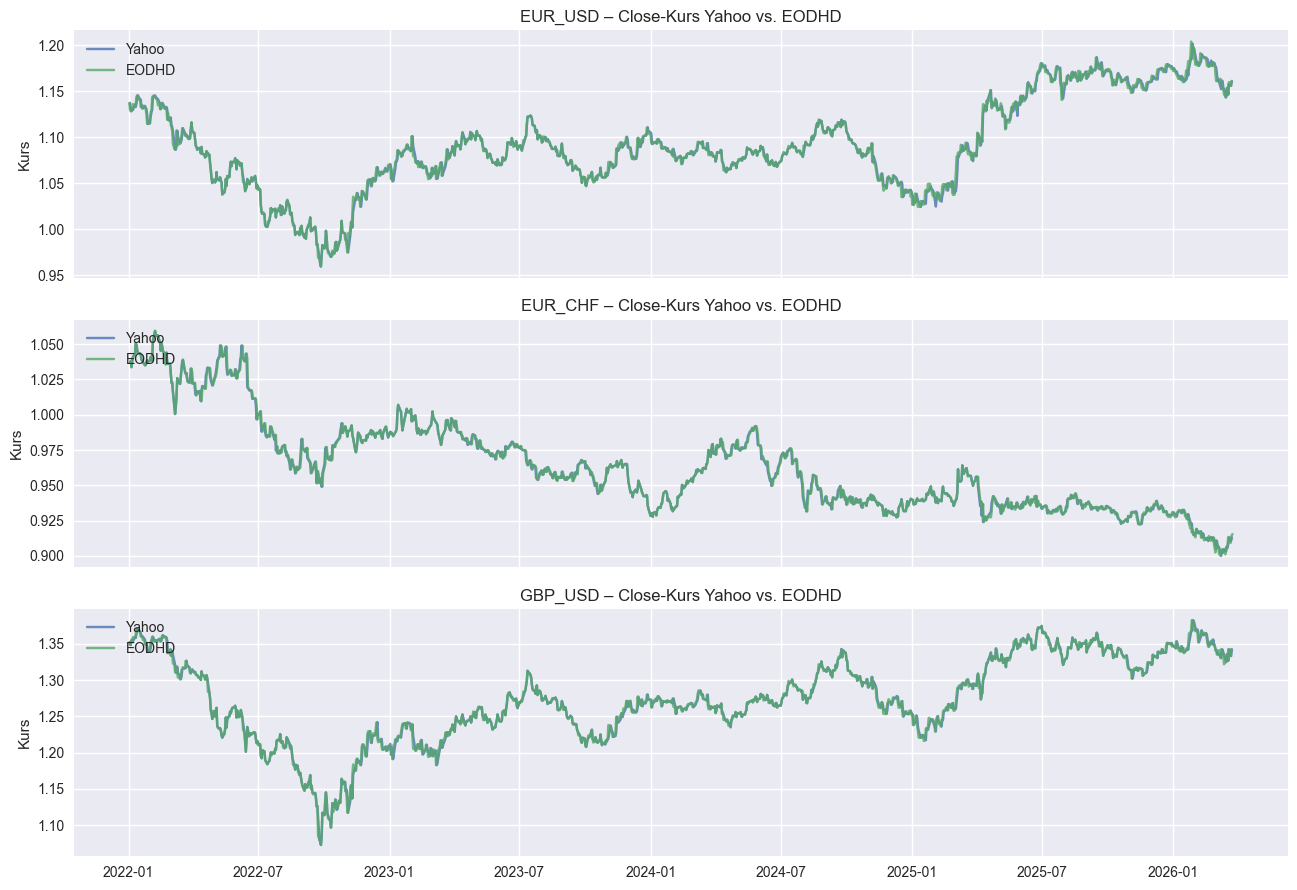

In [4]:
# Visualisierung der Close-Kurse beider Quellen pro Paar
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(13, 9), sharex=True)
for ax, pair in zip(axes, PAIRS):
    ax.plot(raw_data[pair]['yahoo'].index, raw_data[pair]['yahoo']['close'], label='Yahoo', alpha=0.8)
    ax.plot(raw_data[pair]['eodhd'].index, raw_data[pair]['eodhd']['close'], label='EODHD', alpha=0.8)
    ax.set_title(f'{pair} – Close-Kurs Yahoo vs. EODHD')
    ax.set_ylabel('Kurs')
    ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

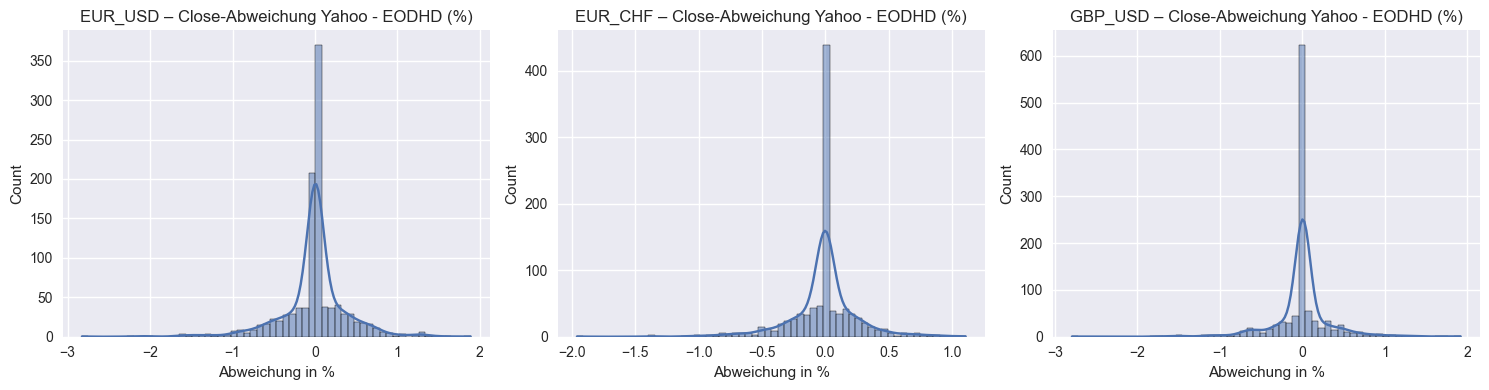

In [5]:
# Verteilung der relativen Close-Abweichung in % (zeigt, wie eng die Quellen beisammen liegen)
fig, axes = plt.subplots(1, len(PAIRS), figsize=(15, 4))
for ax, pair in zip(axes, PAIRS):
    sns.histplot(comparisons[pair]['close_diff_pct'], bins=60, ax=ax, kde=True)
    ax.set_title(f'{pair} – Close-Abweichung Yahoo - EODHD (%)')
    ax.set_xlabel('Abweichung in %')
plt.tight_layout()
plt.show()

## Schritt 2 — Lückenfüllung durch lineare Interpolation

Forex-Kurse sind am Wochenende und an Feiertagen nicht verfügbar. Damit wir später eine **lückenlose Tagesreihe** haben, füllen wir fehlende Tage so:

> Der fehlende Wert ist die **lineare Mitte** zwischen dem letzten verfügbaren und dem nächsten verfügbaren Tag, anteilig nach Abstand.
> Beispiel: Mo = 1.0, Mi = 2.0  →  Di = 1.5.
> Beispiel: Mo = 1.0, Do = 3.0  →  Di = 1.667, Mi = 2.333.

Genau das macht `pandas.DataFrame.interpolate(method='time')` auf einem auf Tagesfrequenz reindizierten DataFrame. Die Interpolation wird **separat für jede Quelle** und für **jede OHLC-Spalte** durchgeführt.

Die Ergebnisse landen in `data/processed/forex/{pair}_{quelle}_interpoliert.csv`.

In [6]:
def fill_gaps(df: pd.DataFrame) -> pd.DataFrame:
    """Reindiziere auf tägliche Frequenz und interpoliere fehlende Tage linear (zeitgewichtet).

    - 'D' = jeder Kalendertag zwischen Min und Max des Index
    - method='time' verwendet die echten Zeitabstände als Gewichte
      (für äquidistante Tage identisch zu method='linear')
    """
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
    out = df.reindex(full_idx)
    out[OHLC_COLS] = out[OHLC_COLS].interpolate(method='time')
    out.index.name = 'date'
    return out

filled_data = {
    pair: {src: fill_gaps(df) for src, df in sources.items()}
    for pair, sources in raw_data.items()
}

# Speichern + kleiner Bericht
for pair, sources in filled_data.items():
    for src, df in sources.items():
        out_path = PROCESSED_DIR / f'{pair}_{src}_interpoliert.csv'
        df.to_csv(out_path)
        original_n = len(raw_data[pair][src])
        filled_n   = len(df)
        print(f'{pair:8s} {src:6s} | {original_n} -> {filled_n} Zeilen ({filled_n - original_n} interpoliert) -> {out_path.name}')

EUR_USD  yahoo  | 1097 -> 1542 Zeilen (445 interpoliert) -> EUR_USD_yahoo_interpoliert.csv
EUR_USD  eodhd  | 1384 -> 1543 Zeilen (159 interpoliert) -> EUR_USD_eodhd_interpoliert.csv
EUR_CHF  yahoo  | 1097 -> 1542 Zeilen (445 interpoliert) -> EUR_CHF_yahoo_interpoliert.csv
EUR_CHF  eodhd  | 1151 -> 1543 Zeilen (392 interpoliert) -> EUR_CHF_eodhd_interpoliert.csv
GBP_USD  yahoo  | 1097 -> 1542 Zeilen (445 interpoliert) -> GBP_USD_yahoo_interpoliert.csv
GBP_USD  eodhd  | 1387 -> 1543 Zeilen (156 interpoliert) -> GBP_USD_eodhd_interpoliert.csv


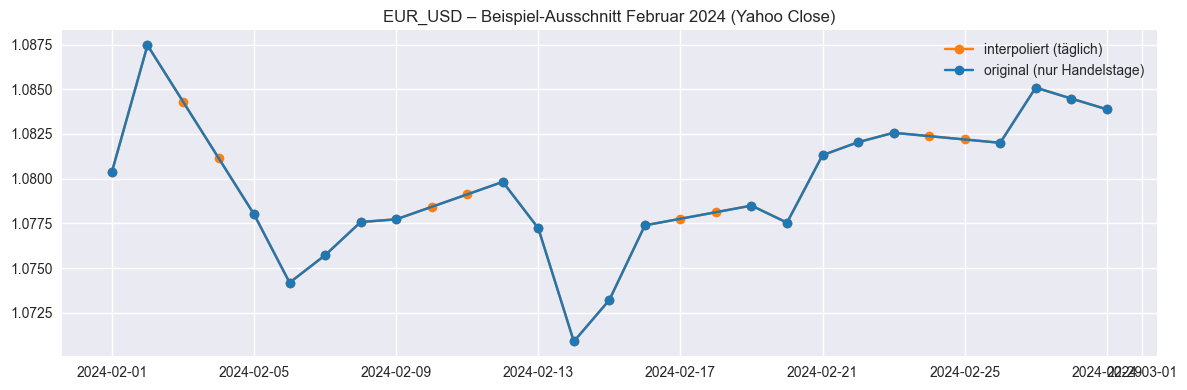

In [7]:
# Kontroll-Plot: ein kleiner Ausschnitt zeigt, dass die Lücken jetzt geschlossen sind
pair = 'EUR_USD'
orig   = raw_data[pair]['yahoo']['close'].loc['2024-02-01':'2024-02-29']
filled = filled_data[pair]['yahoo']['close'].loc['2024-02-01':'2024-02-29']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(filled.index, filled.values, marker='o', label='interpoliert (täglich)', color='tab:orange')
ax.plot(orig.index,   orig.values,   marker='o', label='original (nur Handelstage)', color='tab:blue')
ax.set_title(f'{pair} – Beispiel-Ausschnitt Februar 2024 (Yahoo Close)')
ax.legend()
plt.tight_layout()
plt.show()

## Schritt 3 — Mittelwert über die Quellen

Pro Paar berechnen wir den **Mittelwert von Yahoo und EODHD** für jede OHLC-Spalte. Wichtig:

- als Eingabe verwenden wir die **interpolierten Reihen aus Schritt 2** (`filled_data`). Dadurch haben beide Quellen exakt denselben, lückenlosen Tagesindex – im Output gibt es keine fehlenden Tage.
- pro Datum wird Yahoo-`open` mit EODHD-`open` gemittelt usw. – immer dasselbe Datum, dasselbe Feld

Die Ergebnisse werden als `data/processed/forex/{pair}_quellen_mittelwert.csv` gespeichert.

In [8]:
def average_sources(pair: str) -> pd.DataFrame:
    """Mittelwert OHLC über Yahoo + EODHD auf Basis der interpolierten Reihen aus Schritt 2.

    Da beide Quellen nach der Interpolation denselben täglichen Index haben,
    enthält das Ergebnis jeden Tag im Bereich (keine Lücken).
    """
    yh = filled_data[pair]['yahoo'][OHLC_COLS]
    ed = filled_data[pair]['eodhd'][OHLC_COLS]
    # Auf den gemeinsamen Datumsbereich beschränken (falls die Min/Max-Daten der Quellen leicht abweichen)
    common = yh.index.intersection(ed.index)
    avg = (yh.loc[common] + ed.loc[common]) / 2
    avg.index.name = 'date'
    return avg.sort_index()

averaged_data = {pair: average_sources(pair) for pair in PAIRS}

for pair, df in averaged_data.items():
    out_path = PROCESSED_DIR / f'{pair}_quellen_mittelwert.csv'
    df.to_csv(out_path)
    print(f'{pair:8s} | {len(df):5d} Tage | {df.index.min().date()} – {df.index.max().date()} -> {out_path.name}')

averaged_data['EUR_USD'].head()

EUR_USD  |  1542 Tage | 2022-01-03 – 2026-03-24 -> EUR_USD_quellen_mittelwert.csv
EUR_CHF  |  1542 Tage | 2022-01-03 – 2026-03-24 -> EUR_CHF_quellen_mittelwert.csv
GBP_USD  |  1542 Tage | 2022-01-03 – 2026-03-24 -> GBP_USD_quellen_mittelwert.csv


,open,high,low,close
date,,,,
2022-01-03,1.137342,1.137596,1.128270,1.133773
2022-01-04,1.130199,1.132300,1.127322,1.129262
2022-01-05,1.128420,1.134629,1.127732,1.129731
2022-01-06,1.131161,1.133134,1.128527,1.130425
2022-01-07,1.129543,1.136238,1.129025,1.132844


## Schritt 4 — Kurs vs. News-Sentiment

Jetzt verbinden wir die gemittelten Forex-Kurse mit den News-Sentiment-Daten. Vorgehen:

1. **News einlesen** pro Paar (EODHD-CSV)
2. **Sentiment auf Tagesbasis aggregieren** – pro Tag der **Mittelwert** der Spalte `polarity` aller Artikel
3. Forex-Mittelwert (`close`) und Tages-Sentiment auf demselben Datum joinen
4. **Drei Auflösungen plotten**: täglich, wöchentlich (W-MON, Mittel), monatlich (MS, Mittel)

Auf jedem Plot liegen Kurs (linke y-Achse) und Sentiment (rechte y-Achse) übereinander, damit man visuell prüfen kann, ob hohes Sentiment mit hohen Kursen korreliert.

In [9]:
def load_news(pair: str) -> pd.DataFrame:
    """Lädt EODHD-News-CSV für ein Paar und gibt eine tägliche Sentiment-Reihe zurück.

    Aggregation: pro Tag der **Mittelwert von 'polarity'** über alle Artikel dieses Tages.
    Artikel ohne Sentiment (NaN) werden vom Mittelwert ignoriert.
    """
    path = RAW_DIR / 'news' / 'eodhd' / f'{pair}_news_{DATE_RANGE}.csv'
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date_only'])
    daily = df.groupby('date')['polarity'].mean().to_frame('sentiment')
    return daily.sort_index()

news_daily = {pair: load_news(pair) for pair in PAIRS}

for pair, df in news_daily.items():
    print(f'{pair:8s} | {len(df):5d} Tage mit News | sentiment-range [{df.sentiment.min():.3f}, {df.sentiment.max():.3f}]')

EUR_USD  |  1419 Tage mit News | sentiment-range [-0.952, 0.998]
EUR_CHF  |    11 Tage mit News | sentiment-range [-0.691, 0.997]
GBP_USD  |  1391 Tage mit News | sentiment-range [-0.948, 0.999]


In [10]:
def build_combined(pair: str) -> pd.DataFrame:
    """Kombiniert Forex-Mittelwert (close) mit täglichem Sentiment per Outer-Join auf Datum."""
    fx  = averaged_data[pair][['close']].rename(columns={'close': 'close_avg'})
    nws = news_daily[pair]
    return fx.join(nws, how='outer').sort_index()

combined = {pair: build_combined(pair) for pair in PAIRS}
combined['EUR_USD'].tail()

,close_avg,sentiment
date,,
2026-03-21,1.158088,NaN
2026-03-22,1.156398,-0.880000
2026-03-23,1.158408,-0.177294
2026-03-24,1.161056,-0.021187
2026-03-25,NaN,0.135167


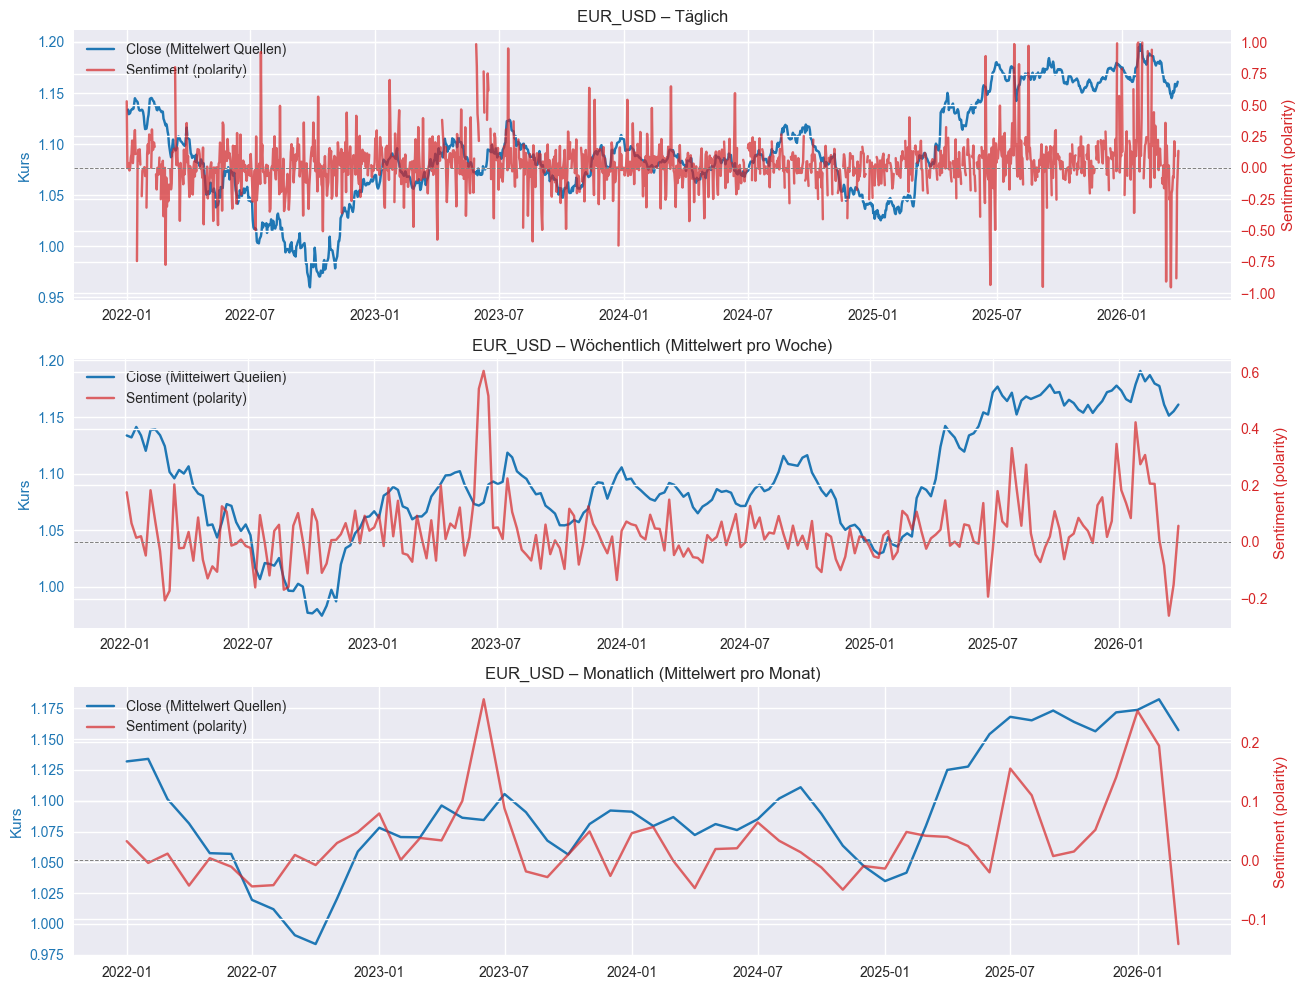

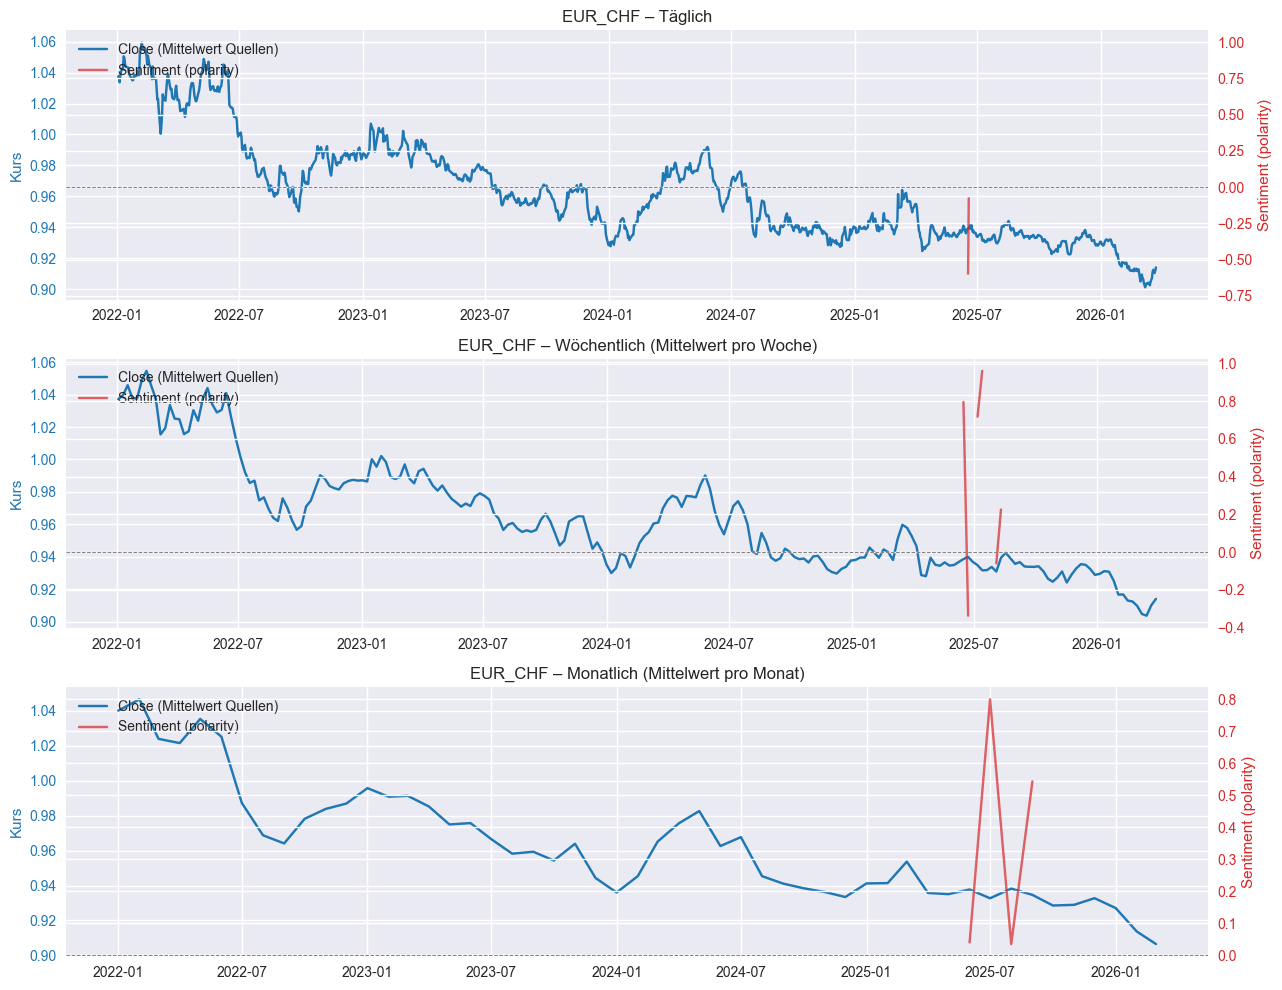

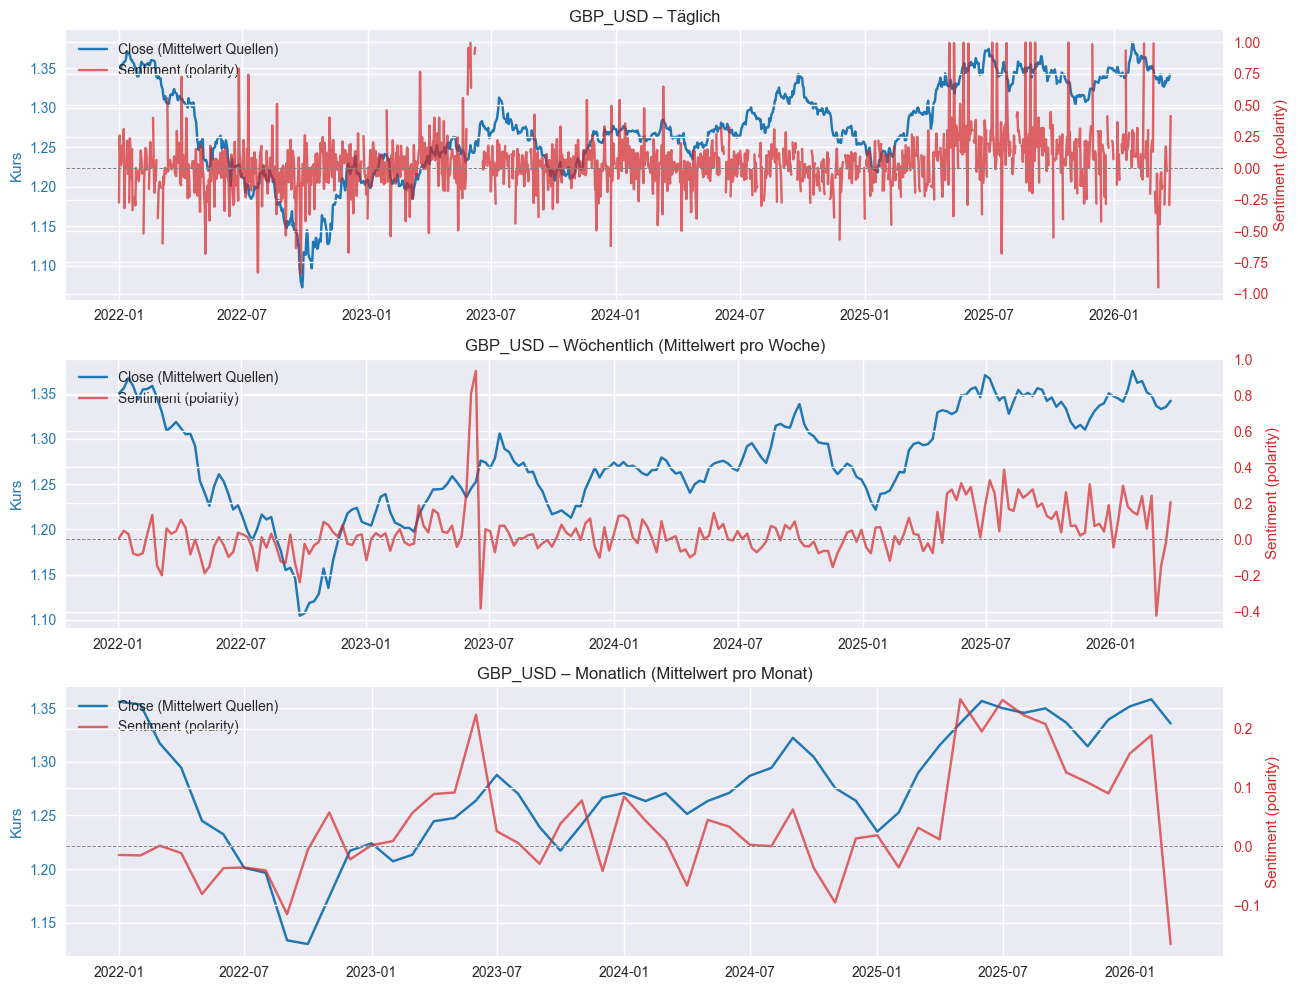

In [11]:
def aggregate(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    """Aggregiert eine kombinierte Reihe (close_avg + sentiment) per Mittelwert auf die gewünschte Frequenz.

    freq: 'D' (täglich = keine Aggregation), 'W-MON' (Woche), 'MS' (Monatsanfang)
    """
    if freq == 'D':
        return df.copy()
    return df.resample(freq).mean()


def plot_overlay(pair: str):
    """Zeichnet drei Overlay-Plots (täglich, wöchentlich, monatlich) für ein Paar."""
    df = combined[pair]
    settings = [
        ('D',     'Täglich'),
        ('W-MON', 'Wöchentlich (Mittelwert pro Woche)'),
        ('MS',    'Monatlich (Mittelwert pro Monat)'),
    ]
    fig, axes = plt.subplots(len(settings), 1, figsize=(13, 10))
    for ax, (freq, label) in zip(axes, settings):
        agg = aggregate(df, freq)
        # Linke Achse: Kurs
        l1, = ax.plot(agg.index, agg['close_avg'], color='tab:blue', label='Close (Mittelwert Quellen)')
        ax.set_ylabel('Kurs', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        # Rechte Achse: Sentiment
        ax2 = ax.twinx()
        l2, = ax2.plot(agg.index, agg['sentiment'], color='tab:red', alpha=0.7, label='Sentiment (polarity)')
        ax2.axhline(0, color='grey', linestyle='--', linewidth=0.7)
        ax2.set_ylabel('Sentiment (polarity)', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax.set_title(f'{pair} – {label}')
        ax.legend([l1, l2], [l1.get_label(), l2.get_label()], loc='upper left')
    plt.tight_layout()
    plt.show()

for pair in PAIRS:
    plot_overlay(pair)

### Korrelationskennzahlen

Zur Ergänzung der visuellen Auswertung berechnen wir die **Pearson-Korrelation** zwischen Kurs (`close_avg`) und Sentiment (`polarity`-Tagesmittel) auf jeder Auflösung. Werte nahe 0 bedeuten keinen linearen Zusammenhang.

In [12]:
rows = []
for pair in PAIRS:
    for freq, label in [('D', 'täglich'), ('W-MON', 'wöchentlich'), ('MS', 'monatlich')]:
        agg = aggregate(combined[pair], freq).dropna()
        if len(agg) > 2:
            corr = agg['close_avg'].corr(agg['sentiment'])
        else:
            corr = np.nan
        rows.append({'pair': pair, 'auflösung': label, 'n': len(agg), 'pearson_r': corr})
pd.DataFrame(rows)

,pair,auflösung,n,pearson_r
0,EUR_USD,täglich,1415,0.154542
1,EUR_USD,wöchentlich,222,0.259541
2,EUR_USD,monatlich,51,0.375963
3,EUR_CHF,täglich,10,-0.115623
4,EUR_CHF,wöchentlich,7,-0.298115
5,EUR_CHF,monatlich,4,-0.996806
6,GBP_USD,täglich,1386,0.230662
7,GBP_USD,wöchentlich,222,0.317256
8,GBP_USD,monatlich,51,0.467164


## Schritt 5 — Diskussion

Hinweise zur Interpretation:

- Das Sentiment-Tagesmittel ist **stark verrauscht**, weil pro Tag oft nur wenige Artikel pro Paar vorhanden sind. Wöchentliche und monatliche Aggregation glätten das Bild und sind in der Regel aussagekräftiger.
- `polarity` ist ein **Niveauwert**, der Forex-Kurs ebenfalls. Eine hohe Pearson-Korrelation auf den **Niveaus** kann irreführend sein – für eine ernsthafte Auswertung sollte man ergänzend **Renditen** (`close.pct_change()`) gegen das Sentiment vergleichen oder lagged Cross-Correlations berechnen. Das ist hier bewusst ausgespart und wäre ein nächster Schritt.
- MetaTrader wurde in diesem Notebook **bewusst ausgelassen**; sobald die Daten für alle drei Paare vorliegen, kann der Mittelwert in Schritt 3 auf drei Quellen erweitert werden.

**Erzeugte Dateien** in `data/processed/forex/`:
- `{pair}_yahoo_interpoliert.csv` und `{pair}_eodhd_interpoliert.csv` (Schritt 2)
- `{pair}_quellen_mittelwert.csv` (Schritt 3)
